# (26) EAT method – bias of moments plot (theory)

**Project: `_PoissonGradEstim`**

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:0, dtype: torch.float32  ———  host: mach

## Make fig dir

In [3]:
fig_dir = fig_base_dir / f'{project_name}_figs-({now()})'
fig_dir.mkdir(exist_ok=True)

os.listdir(str(fig_dir))

['dist_moments_theory.pdf']

## Theorey fun

In [4]:
# Helper functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softplus(x):
    return np.log(1 + np.exp(x))

# Sigmoid quantities
def c_sigmoid(tau):
    return tau * softplus(1/tau)

def v_sigmoid(tau):
    return tau * (softplus(1/tau) - sigmoid(1/tau))

def F_sigmoid(tau):
    return v_sigmoid(tau) / c_sigmoid(tau)

# Cubic quantities
def c_cubic(tau):
    result = np.ones_like(tau)
    mask = tau > 1
    beta = (1 + tau[mask]) / (2 * tau[mask])
    result[mask] = tau[mask] * beta**3 * (2 - beta)
    return result

def v_cubic(tau):
    result = 1 - 9*tau/35
    mask = tau > 1
    beta = (1 + tau[mask]) / (2 * tau[mask])
    result[mask] = tau[mask] * (18*beta**5/5 - 4*beta**6 + 8*beta**7/7)
    return result

def F_cubic(tau):
    return v_cubic(tau) / c_cubic(tau)

## Fig fun

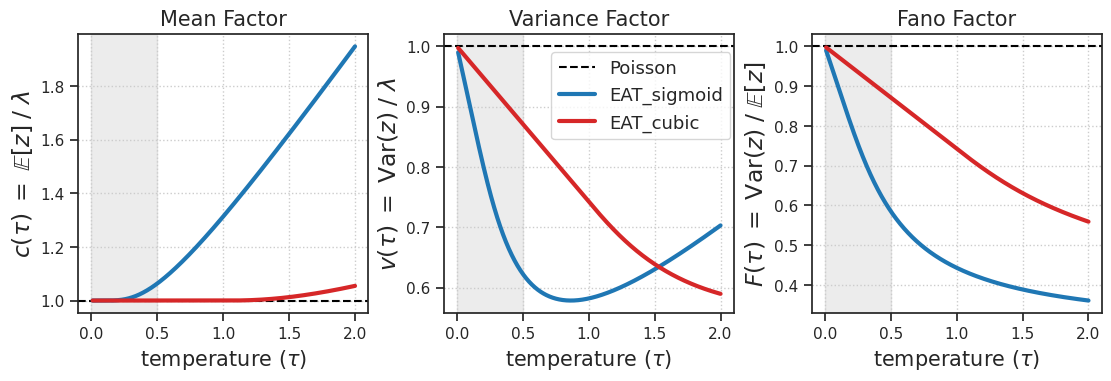

In [18]:
# Set up tau range
tau = np.linspace(0.01, 2.0, 1000)

# Create figure with 3 subplots
fig, axes = create_figure(1, 3, figsize=(11, 3.7))

for ax in axes.flat:
    ax.axvspan(0, 0.5, alpha=0.15, color='gray', zorder=0)

# Plot c(tau) - Mean factor
ax1 = axes[0]
ax1.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax1.plot(tau, c_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax1.plot(tau, c_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

ax1.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax1.set_ylabel(r'$c(\tau) \;=\; \mathbb{E}[z] \;/\; \lambda$', fontsize=17)
ax1.set_title('Mean Factor', fontsize=15)
# ax1.legend(loc='upper left')
# ax1.grid(True, alpha=0.3)
# ax1.set_xlim(0, 1.5)
# ax1.set_ylim(0.9, 1.6)

# Plot v(tau) - Variance factor
ax2 = axes[1]
ax2.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax2.plot(tau, v_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax2.plot(tau, v_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

ax2.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax2.set_ylabel(r'$v(\tau) \;=\; \mathrm{Var}(z) \;/\; \lambda$', fontsize=17)
ax2.set_title('Variance Factor', fontsize=15)
ax2.legend(loc='best', fontsize=13)
# ax2.grid(True, alpha=0.3)
# ax2.set_xlim(0, 1.5)
# ax2.set_ylim(0.4, 1.05)

# Plot F(tau) - Fano factor
ax3 = axes[2]
ax3.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax3.plot(tau, F_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax3.plot(tau, F_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

# ax3.axhspan(0.5, 1.0, alpha=0.1, color='green', label='Cortical range')
ax3.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax3.set_ylabel(r'$F(\tau) \;=\; \mathrm{Var}(z) \;/\; \mathbb{E}[z]$', fontsize=17)
ax3.set_title('Fano Factor', fontsize=15)
# ax3.legend(loc='upper right')
# ax3.grid(True, alpha=0.3)
# ax3.set_xlim(0, 1.5)
# ax3.set_ylim(0.3, 1.05)

move_legend(ax2, (0.34, 0.59))


add_grid(axes)

plt.show()

In [19]:
fig.savefig(fig_dir / f'dist_moments_theory.pdf', bbox_inches='tight')